In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller , acf , pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess


from sklearn.metrics import mean_absolute_error, mean_squared_error


In [2]:
passengers = [
    112,118,132,129,121,135,148,148,136,119,104,118,
    115,126,141,135,125,149,170,170,158,133,114,140,
    145,150,178,163,172,178,199,199,184,162,146,166,
    171,180,193,181,183,218,230,242,209,191,172,194,
    196,196,236,235,229,243,264,272,237,211,180,201,
    204,188,235,227,234,264,302,293,259,229,203,229,
    242,233,267,269,270,315,364,347,312,274,237,278,
    284,277,317,313,318,374,413,405,355,306,271,306,
    315,301,356,348,355,422,465,467,404,347,305,336,
    340,318,362,348,363,435,491,505,404,359,310,337,
    360,342,406,396,420,472,548,559,463,407,362,405,
    417,391,419,461,472,535,622,606,508,461,390,432
]

dates = pd.date_range(start="1949-01-01", periods=len(passengers), freq="MS") # MS = month start
ts = pd.Series(passengers, index = dates, name= "passengers")

print(ts.head(12))
print(f"\n Total oservations : {len(ts)} | From {ts.index.min().date()} to {ts.index.max().date()}")



1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
1949-06-01    135
1949-07-01    148
1949-08-01    148
1949-09-01    136
1949-10-01    119
1949-11-01    104
1949-12-01    118
Freq: MS, Name: passengers, dtype: int64

 Total oservations : 144 | From 1949-01-01 to 1960-12-01


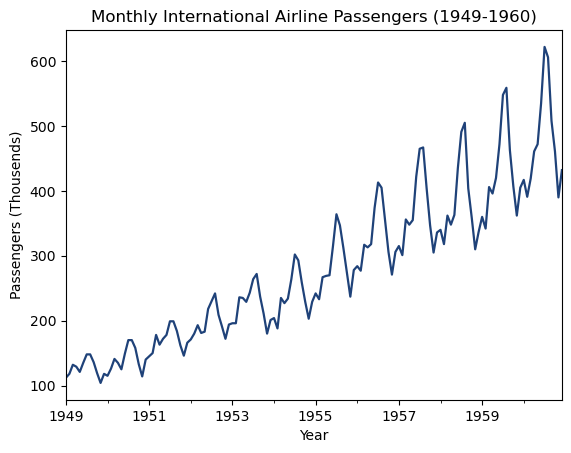

In [3]:
ts.plot(title="Monthly International Airline Passengers (1949-1960)", color = "#1f4279",  lw = 1.6)
plt.ylabel("Passengers (Thousends)")
plt.xlabel("Year")
plt.show()

Text(0.5, 1.01, 'Additive Decomposition Of AirPassengers')

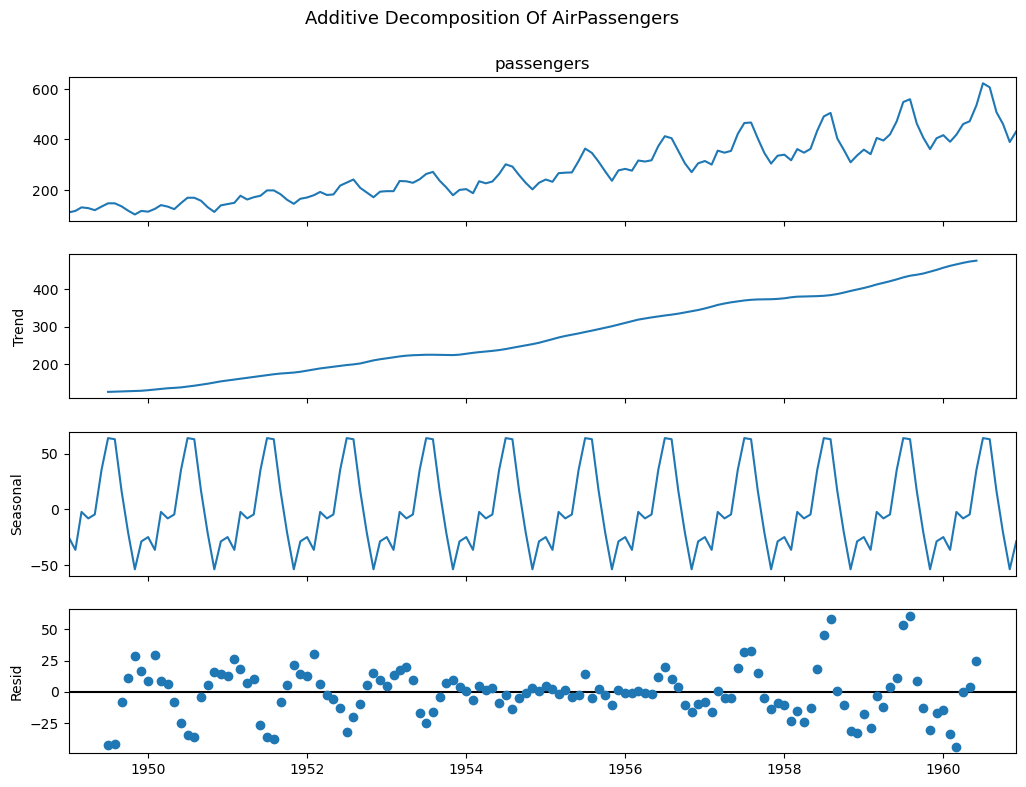

In [4]:
decomp = seasonal_decompose(ts, model= "additive", period = 12)

fig = decomp.plot()
fig.set_size_inches(11,8)
fig.suptitle("Additive Decomposition Of AirPassengers", y = 1.01, fontsize = 13)

finding the stationary point:

ARMA/ARIMA models assume the series is stationary. A stationary series has statistical properites that contains 
constant mean (no trends)
constant cariance (spread doesn't grow or shrink )
Autocorrelation depends on the gap between the data points


Testing for stationarity : the Augmented Dickey-Fuller (ADF) test: 
The ADF test is a formal hypothesis test:
NUll hypothesis H0 = the series is non stationary (has a "unit root")
Alternative H1 : the series is sttionary.

we look at the p-value

p-value 

In [5]:
def adf_report(series, name="Series"):
    series = series.dropna()

    result = adfuller(series, autolag="AIC")
    stat, pvalue, _, nobs, crit, _ = result

    print(f"ADF Test on '{name}'")
    print(f"   ADF Statistic : {stat:.4f}")
    print(f"   P-value       : {pvalue:.4f}")
    print(f"   # Obs Used    : {nobs}")

    print("Critical Values:")
    for k, v in crit.items():
        print(f"   {k:>4}: {v:.4f}")

    verdict = "STATIONARY" if pvalue <= 0.05 else "NON-STATIONARY"
    print(f"\nVerdict (5% level): {verdict}")

    return pvalue

_ = adf_report(ts, "Raw Passengers")

ADF Test on 'Raw Passengers'
   ADF Statistic : 0.8154
   P-value       : 0.9919
   # Obs Used    : 130
Critical Values:
     1%: -3.4817
     5%: -2.8840
    10%: -2.5788

Verdict (5% level): NON-STATIONARY


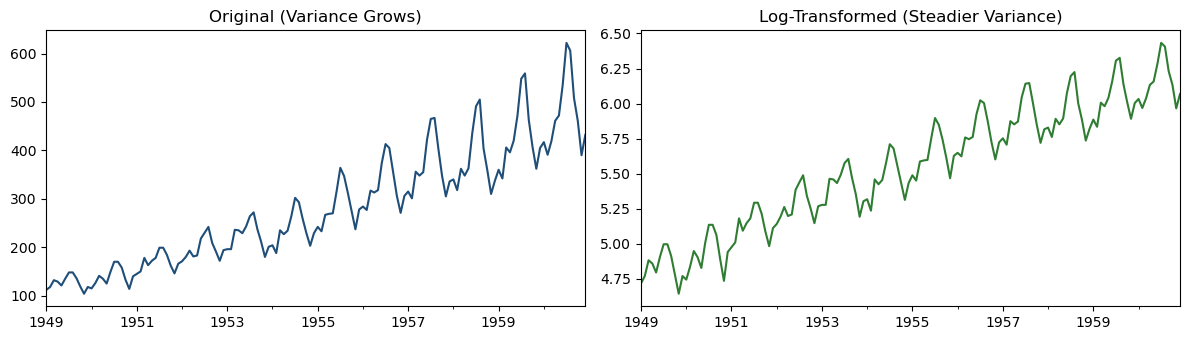

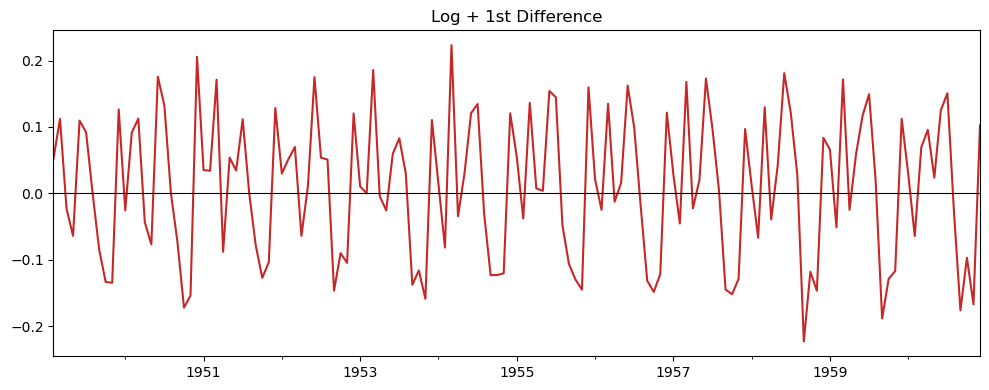

ADF Test on 'Log + 1st Difference'
   ADF Statistic : -2.7171
   P-value       : 0.0711
   # Obs Used    : 128
Critical Values:
     1%: -3.4825
     5%: -2.8844
    10%: -2.5790

Verdict (5% level): NON-STATIONARY


In [9]:
# Step 1: Log-transform to stabilize variance
ts_log = np.log(ts)

# Plot original and log-transformed series
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))

ts.plot(ax=ax[0], color="#1f4e79")
ax[0].set_title("Original (Variance Grows)")

ts_log.plot(ax=ax[1], color="#2e7d32")
ax[1].set_title("Log-Transformed (Steadier Variance)")

plt.tight_layout()
plt.show()

# Step 2: First-order differencing
ts_log_diff = ts_log.diff().dropna()

# Plot differenced series
plt.figure(figsize=(10, 4))
ts_log_diff.plot(title="Log + 1st Difference", color="#c62828")

plt.axhline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

# Step 3: ADF Test
_ = adf_report(ts_log_diff, "Log + 1st Difference")

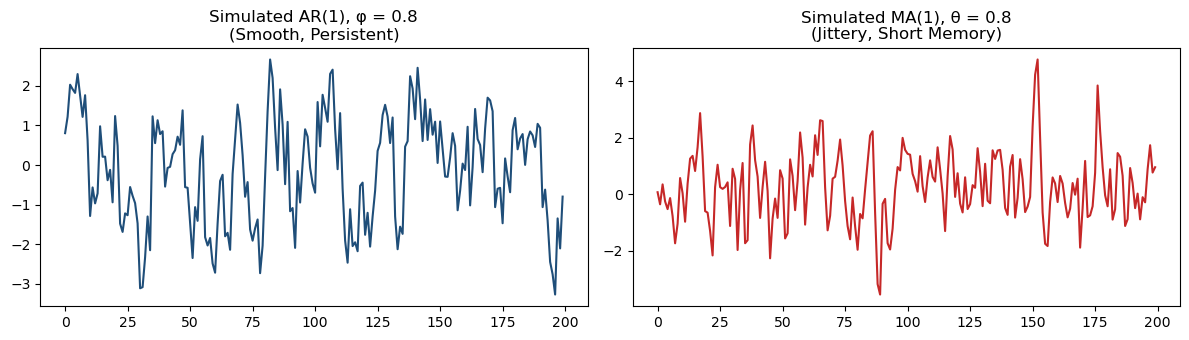

In [10]:
# AR(1) with phi = 0.8 -> ar = [1, -0.8]
ar1 = ArmaProcess(ar=[1, -0.8], ma=[1]).generate_sample(nsample=200)

# MA(1) with theta = 0.8 -> ma = [1, 0.8]
ma1 = ArmaProcess(ar=[1], ma=[1, 0.8]).generate_sample(nsample=200)

# Plot both series
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))

ax[0].plot(ar1, color="#1f4e79")
ax[0].set_title("Simulated AR(1), φ = 0.8\n(Smooth, Persistent)")

ax[1].plot(ma1, color="#c62828")
ax[1].set_title("Simulated MA(1), θ = 0.8\n(Jittery, Short Memory)")

plt.tight_layout()
plt.show()

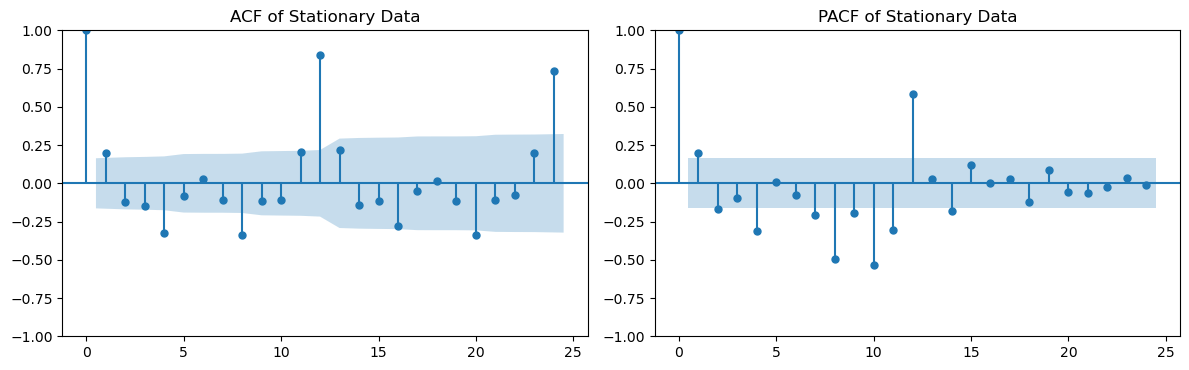

In [11]:
# Plot ACF and PACF of the stationary series
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))

plot_acf(ts_log_diff, lags=24, ax=ax[0])
ax[0].set_title("ACF of Stationary Data")

plot_pacf(ts_log_diff, lags=24, ax=ax[1], method="ywm")
ax[1].set_title("PACF of Stationary Data")

plt.tight_layout()
plt.show()

Train: 120 months  (1949-01-01 -> 1958-12-01)
Test : 24 months  (1959-01-01 -> 1960-12-01)


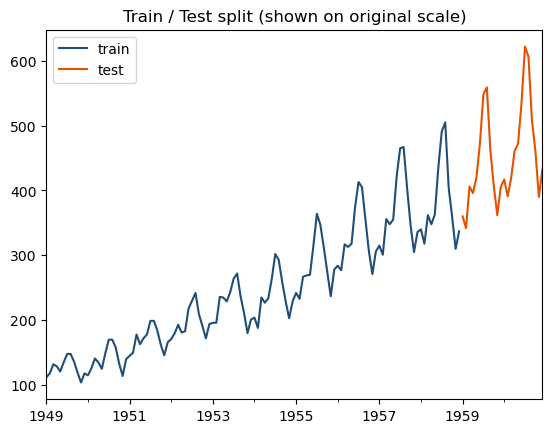

In [12]:
# We model the LOG series (variance stabilized) and let ARIMA handle differencing via d.
train = ts_log.iloc[:-24]
test  = ts_log.iloc[-24:]

print(f"Train: {len(train)} months  ({train.index.min().date()} -> {train.index.max().date()})")
print(f"Test : {len(test)} months  ({test.index.min().date()} -> {test.index.max().date()})")

ax = np.exp(train).plot(label="train", color="#1f4e79")
np.exp(test).plot(ax=ax, label="test", color="#e65100")
plt.title("Train / Test split (shown on original scale)")
plt.legend(); plt.show()

In [13]:
arma = ARIMA(train, order=(2, 0, 2))
arma_fit = arma.fit()
print(arma_fit.summary())

c:\Users\LENOVO\anaconda3\envs\dsaa\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\LENOVO\anaconda3\envs\dsaa\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:             passengers   No. Observations:                  120
Model:                 ARIMA(2, 0, 2)   Log Likelihood                 104.236
Date:                Thu, 09 Jul 2026   AIC                           -196.472
Time:                        08:30:16   BIC                           -179.747
Sample:                    01-01-1949   HQIC                          -189.680
                         - 12-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3889      0.214     25.179      0.000       4.969       5.808
ar.L1          0.3227      0.301      1.074      0.283      -0.266       0.912
ar.L2          0.6112      0.285      2.148      0.0

In [14]:
arima = ARIMA(train, order=(2, 1, 2))
arima_fit = arima.fit()
print(arima_fit.summary())

print("\n--- AIC comparison (lower is better) ---")
print(f"ARMA(2,0,2)  AIC = {arma_fit.aic:.2f}")
print(f"ARIMA(2,1,2) AIC = {arima_fit.aic:.2f}")

                               SARIMAX Results                                
Dep. Variable:             passengers   No. Observations:                  120
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 107.730
Date:                Thu, 09 Jul 2026   AIC                           -205.461
Time:                        08:31:20   BIC                           -191.565
Sample:                    01-01-1949   HQIC                          -199.818
                         - 12-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2555      0.191      1.336      0.181      -0.119       0.630
ar.L2          0.2383      0.237      1.007      0.314      -0.226       0.702
ma.L1         -0.1103      0.142     -0.775      0.4